Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

C:\Users\Lalo\AppData\Local\Temp\ipykernel_18304\2989008919.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([df[df['Churn']=='No']['MonthlyCharges'],


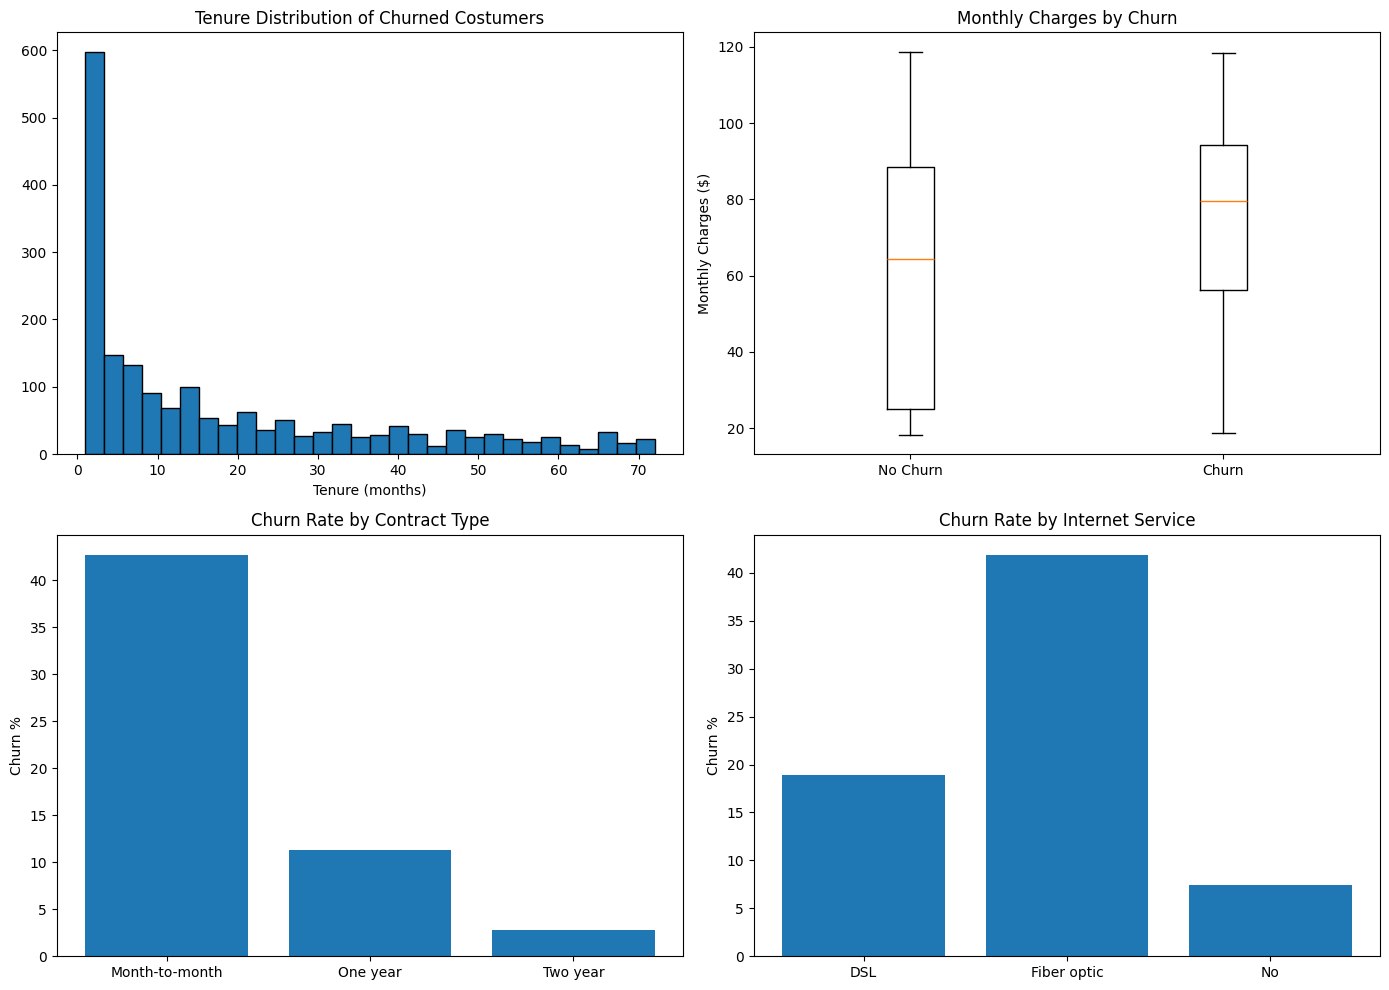

Complete


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load data
df = pd.read_csv('../data/raw/Telco_customer_churn.csv')

#Basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names and types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

#Target variable analysis
print("\n ---- Churn Distribution ----")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

#Statistical summary
print("\n ---- Numeric Features ----")
print(df.describe())

#Categorical features
print("\n ---- Categorical Features ----")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

#Analyze churn patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#1. Churn by tenure
df_churn = df[df['Churn'] == 'Yes']
axes[0, 0].hist(df_churn['tenure'], bins=30, edgecolor='black')
axes[0, 0].set_title('Tenure Distribution of Churned Costumers')
axes[0, 0].set_xlabel('Tenure (months)')

#2. Churn by monthly charges
axes[0, 1].boxplot([df[df['Churn']=='No']['MonthlyCharges'],
                    df[df['Churn']=='Yes']['MonthlyCharges']],
                    labels=['No Churn', 'Churn'])
axes[0, 1].set_title('Monthly Charges by Churn')
axes[0, 1].set_ylabel('Monthly Charges ($)')

#3. Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100)
axes[1, 0].bar(contract_churn.index, contract_churn.values)
axes[1, 0].set_title('Churn Rate by Contract Type')
axes[1, 0].set_ylabel('Churn %')

#4. Churn by internet service
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) *100)
axes[1, 1].bar(internet_churn.index, internet_churn.values)
axes[1, 1].set_title('Churn Rate by Internet Service')
axes[1, 1].set_ylabel('Churn %')

plt.tight_layout()
plt.savefig('../data/churn_analysis.png', dpi=300)
plt.show()

print("Complete")